In [27]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df=pd.read_csv("../Raw Datasets/data_main1.csv")
df['shortlisted']=df['shortlisted'].map({'Yes':1,'No':0}) # for Numerical analysis
print("INITIAL DATA",df.shape)
df=df.drop('project_count',axis=1)
df=df.drop('github_activity',axis=1)
print(df)
print(df.shape)
df.columns

INITIAL DATA (30000, 7)
       years_experience  skills_match_score education_level  resume_length  \
0                     6                84.7       Bachelors            234   
1                     3                59.1         Masters            502   
2                    12               100.0         Masters            753   
3                    14                66.8     High School            529   
4                    10                99.6       Bachelors            754   
...                 ...                 ...             ...            ...   
29995                 9                77.4       Bachelors            691   
29996                 5                77.8       Bachelors            473   
29997                 1                64.6       Bachelors            247   
29998                 7                94.8       Bachelors            584   
29999                14                77.3         Masters            694   

       shortlisted  
0                0

Index(['years_experience', 'skills_match_score', 'education_level',
       'resume_length', 'shortlisted'],
      dtype='str')

NULL HANDLING

In [21]:
df.isnull().sum()

years_experience      0
skills_match_score    0
education_level       0
resume_length         0
shortlisted           0
dtype: int64

DATA STATISTICS (NUMERICAL Datapts)

In [22]:
df.describe()

,years_experience,skills_match_score,resume_length,shortlisted
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,7.506567,73.682653,572.584700,0.698867
std,4.624104,16.765909,178.709918,0.458758
min,0.000000,0.500000,150.000000,0.000000
25%,3.750000,62.100000,441.000000,0.000000
50%,7.000000,74.300000,574.000000,1.000000
75%,12.000000,86.500000,709.000000,1.000000
max,15.000000,100.000000,900.000000,1.000000


FINAL DROPS IMPLEMENTED DATA CLEANED

In [33]:
df.to_csv("..\Datasets\data_main1_cleaned.csv",index=False)

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\karti\AppData\Local\Temp\ipykernel_5920\442099276.py:1: SyntaxWarning: invalid escape sequence '\D'
  df.to_csv("..\Datasets\data_main1_cleaned.csv",index=False)


HELPER FUNCS

In [ ]:
def avg(arr):
    return sum(arr)/len(arr)

GRAPHICAL REPRESENTATION FOR CORRELATION AND OUTLIERS

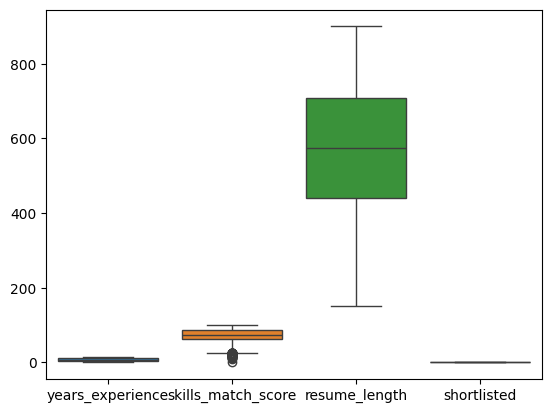

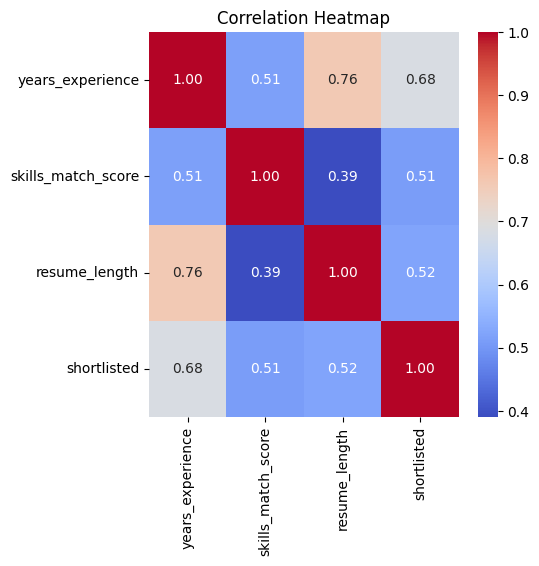

In [32]:
sns.boxplot(data=df)
plt.show()
print()
corrmat=df.corr(numeric_only=True)
plt.figure(figsize=(5,5))
sns.heatmap(corrmat,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

TARGET (SHORTLISTED) Variable Labels

In [30]:
print(df['shortlisted'].value_counts())
df["shortlisted"].value_counts(normalize=True)*100
df.corr(numeric_only=True) #Numeric values correlation with each value


shortlisted
1    20966
0     9034
Name: count, dtype: int64


,years_experience,skills_match_score,resume_length,shortlisted
years_experience,1.000000,0.514022,0.759848,0.684845
skills_match_score,0.514022,1.000000,0.390144,0.509375
resume_length,0.759848,0.390144,1.000000,0.522505
shortlisted,0.684845,0.509375,0.522505,1.000000


Resume Length LABELS

In [54]:
x=avg(df['resume_length'])
print(f"Avg Res len-{x}")
above=df[df['resume_length']>x]
print("\nAbove avg")
print(above['shortlisted'].value_counts())
below=df[df['resume_length']<=x]
print("\nBelow average:")
print(below['shortlisted'].value_counts())


Avg Res len-572.5847

Above avg
shortlisted
Yes    13691
No      1423
Name: count, dtype: int64

Below average:
shortlisted
No     7611
Yes    7275
Name: count, dtype: int64


EDUCATION LEVEL LABELS

In [ ]:
print(df['education_level'].unique())
print("-------By Value-----")
print(df['education_level'].value_counts())
print()
print("-------By Percentages-----")
print(df['education_level'].value_counts(normalize=True)*100)

<StringArray>
['Bachelors', 'Masters', 'High School', 'PhD']
Length: 4, dtype: str
-------By Value-----
education_level
Bachelors      13461
Masters        10524
PhD             3024
High School     2991
Name: count, dtype: int64

-------By Percentages-----
education_level
Bachelors      44.87
Masters        35.08
PhD            10.08
High School     9.97
Name: proportion, dtype: float64


Years Experience Labels

In [58]:
av=avg(df['years_experience'])
print("Average years of experience",av)
above=df[df['years_experience']>av]
print("\nAbove avg")
print(above['shortlisted'].value_counts())
below=df[df['years_experience']<=av]
print("\nBelow average:")
print(below['shortlisted'].value_counts())

Average years of experience 7.506566666666667

Above avg
shortlisted
Yes    14615
No       372
Name: count, dtype: int64

Below average:
shortlisted
No     8662
Yes    6351
Name: count, dtype: int64
